In [8]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optuna
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP
import shap

# Model persistence
import joblib

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 70)
print("  ANN (MLP) & SVR — CWR PREDICTION MODEL")
print("  ML-Based Predictive Irrigation System for Paddy Cultivation")
print("=" * 70)
print(f"\n✓ All libraries imported successfully!")
print(f"  Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


  ANN (MLP) & SVR — CWR PREDICTION MODEL
  ML-Based Predictive Irrigation System for Paddy Cultivation

✓ All libraries imported successfully!
  Timestamp: 2026-02-26 20:10:53


In [9]:
dataset_filename = 'Data/paddy_CWR_dataset_20260214_202705.csv'  # UPDATE PATH IF NEEDED

df = pd.read_csv(dataset_filename)

print(f"✓ Dataset loaded: {dataset_filename}")
print(f"\n  Shape       : {df.shape}")
print(f"  Features    : {df.shape[1] - 1}")
print(f"  Samples     : {df.shape[0]}")

print("\nFirst 5 samples:")
display(df.head())

print("\nDataset Statistics:")
display(df.describe())

# Missing values check
missing = df.isnull().sum()
if missing.sum() == 0:
    print("\n✓ No missing values detected")
else:
    print(f"\n⚠ Missing values:\n{missing[missing > 0]}")

# CWR distribution summary
print("\nCWR Distribution:")
print(f"  Min    : {df['CWR_mm'].min():.2f} mm")
print(f"  Max    : {df['CWR_mm'].max():.2f} mm")
print(f"  Mean   : {df['CWR_mm'].mean():.2f} mm")
print(f"  Median : {df['CWR_mm'].median():.2f} mm")
print(f"  Std    : {df['CWR_mm'].std():.2f} mm")


✓ Dataset loaded: Data/paddy_CWR_dataset_20260214_202705.csv

  Shape       : (4000, 7)
  Features    : 6
  Samples     : 4000

First 5 samples:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
0,3.85,98.7,35.4,9.54,0.48,1,9.72
1,0.00,47.9,31.2,5.39,0.00,5,45.38
2,3.64,97.9,29.1,9.98,2.64,1,8.43
3,0.00,77.7,89.7,4.81,15.74,5,0.00
4,8.66,94.3,17.1,9.54,3.17,4,7.31



Dataset Statistics:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000
mean,4.205855,85.213350,57.290900,6.823190,3.279750,3.00000,26.444840
std,3.611346,14.622071,24.500311,1.725265,4.878442,1.41439,34.461308
min,0.000000,45.200000,15.000000,4.000000,0.000000,1.00000,0.000000
25%,0.110000,75.100000,36.300000,5.500000,0.000000,2.00000,3.000000
50%,4.425000,92.100000,57.400000,6.320000,0.055000,3.00000,12.125000
75%,7.052500,96.100000,78.200000,8.760000,4.992500,4.00000,28.727500
max,12.000000,100.000000,100.000000,10.000000,19.970000,5.00000,120.000000



✓ No missing values detected

CWR Distribution:
  Min    : 0.00 mm
  Max    : 120.00 mm
  Mean   : 26.44 mm
  Median : 12.12 mm
  Std    : 34.46 mm


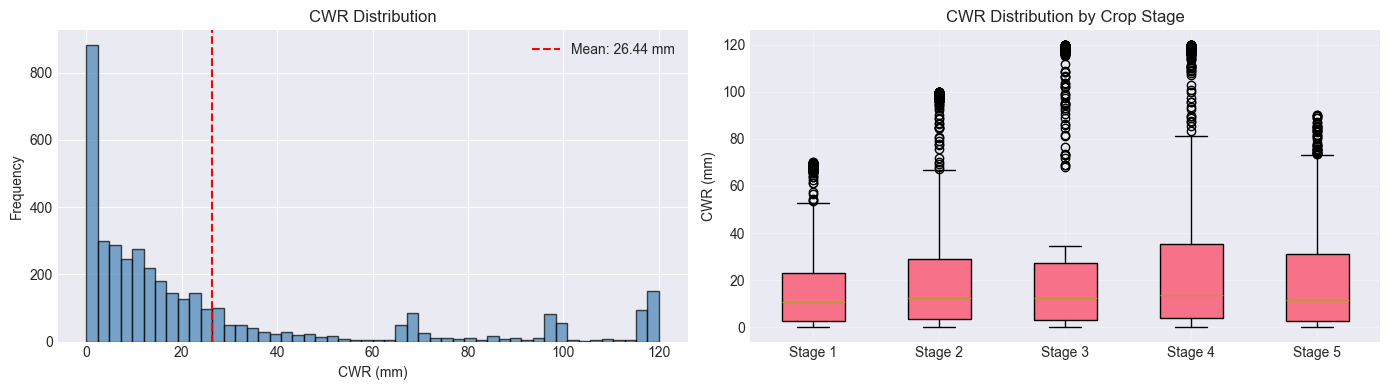

✓ EDA plot saved → ./Visualisation/dataset_overview.png


In [10]:
import os
os.makedirs('./Visualisation', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# CWR Histogram
axes[0].hist(df['CWR_mm'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['CWR_mm'].mean(), color='red', linestyle='--', label=f"Mean: {df['CWR_mm'].mean():.2f} mm")
axes[0].set_xlabel('CWR (mm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('CWR Distribution')
axes[0].legend()

# CWR by Crop Stage
axes[1].boxplot(
    [df[df['Crop_Stage'] == i]['CWR_mm'].values for i in range(1, 6)],
    labels=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5'],
    patch_artist=True
)
axes[1].set_ylabel('CWR (mm)')
axes[1].set_title('CWR Distribution by Crop Stage')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./Visualisation/dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ EDA plot saved → ./Visualisation/dataset_overview.png")


In [11]:
feature_columns = ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%',
                   'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']
target_column = 'CWR_mm'

X = df[feature_columns].copy()
y = df[target_column].copy()

print(f"Feature Matrix (X) : {X.shape}")
print(f"Target Variable (y): {y.shape}")
print(f"Features           : {list(X.columns)}")

# Step 1: Split off 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=df['Crop_Stage']
)

# Step 2: Split remaining 85% → 70% train / 15% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,           # 0.176 × 0.85 ≈ 0.15 of total
    random_state=42,
    stratify=X_temp['Crop_Stage']
)

print("\n" + "=" * 70)
print("DATA SPLIT SUMMARY")
print("=" * 70)
print(f"  Training set  : {len(X_train):4d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation set: {len(X_val):4d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test set      : {len(X_test):4d} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Total         : {len(X):4d} samples")

print("\nCrop Stage Distribution:")
print(f"{'Stage':<10} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 38)
for stage in range(1, 6):
    tr = (X_train['Crop_Stage'] == stage).sum()
    vl = (X_val['Crop_Stage'] == stage).sum()
    te = (X_test['Crop_Stage'] == stage).sum()
    print(f"  Stage {stage}   {tr:>8} {vl:>8} {te:>8}")

print("\n✓ Data split complete!")


Feature Matrix (X) : (4000, 6)
Target Variable (y): (4000,)
Features           : ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%', 'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']

DATA SPLIT SUMMARY
  Training set  : 2801 samples (70.0%)
  Validation set:  599 samples (15.0%)
  Test set      :  600 samples (15.0%)
  Total         : 4000 samples

Crop Stage Distribution:
Stage         Train      Val     Test
--------------------------------------
  Stage 1        560      120      120
  Stage 2        561      119      120
  Stage 3        560      120      120
  Stage 4        560      120      120
  Stage 5        560      120      120

✓ Data split complete!


In [12]:
scaler = StandardScaler()

# Fit ONLY on training data — transform val and test separately
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Combined train+val for final model retraining after tuning
X_trainval_scaled = scaler.transform(
    pd.concat([X_train, X_val], axis=0)
)
y_trainval = pd.concat([y_train, y_val], axis=0)

print("✓ StandardScaler fitted on training data only")
print(f"\n  X_train_scaled shape   : {X_train_scaled.shape}")
print(f"  X_val_scaled shape     : {X_val_scaled.shape}")
print(f"  X_test_scaled shape    : {X_test_scaled.shape}")
print(f"  X_trainval_scaled shape: {X_trainval_scaled.shape}")

# Save scaler for deployment
joblib.dump(scaler, './Models/scaler_ann_svr.pkl')
print("\n✓ Scaler saved → ./Models/scaler_ann_svr.pkl")


✓ StandardScaler fitted on training data only

  X_train_scaled shape   : (2801, 6)
  X_val_scaled shape     : (599, 6)
  X_test_scaled shape    : (600, 6)
  X_trainval_scaled shape: (3400, 6)

✓ Scaler saved → ./Models/scaler_ann_svr.pkl


In [13]:
import os
os.makedirs('./Models', exist_ok=True)

def mlp_objective(trial):
    # Architecture
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers   = tuple(
        trial.suggest_int(f'n_units_l{i}', 32, 256, step=32)
        for i in range(n_layers)
    )

    # Hyperparameters
    activation    = trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic'])
    alpha         = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    learning_rate = trial.suggest_categorical('learning_rate', ['constant', 'adaptive'])
    lr_init       = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [32, 64, 128])

    model = MLPRegressor(
        hidden_layer_sizes=layers,
        activation=activation,
        alpha=alpha,
        learning_rate=learning_rate,
        learning_rate_init=lr_init,
        batch_size=batch_size,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )

    kf     = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    return -scores.mean()   # minimize RMSE


print("=" * 70)
print("OPTUNA HYPERPARAMETER TUNING — MLP (ANN)")
print("=" * 70)

mlp_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='MLP_CWR'
)
mlp_study.optimize(mlp_objective, n_trials=100, show_progress_bar=True)

print(f"\n✓ MLP Tuning Complete!")
print(f"  Best CV RMSE : {mlp_study.best_value:.4f} mm")
print(f"  Best Params  :")
for k, v in mlp_study.best_params.items():
    print(f"    {k:<30}: {v}")


OPTUNA HYPERPARAMETER TUNING — MLP (ANN)


  0%|          | 0/100 [00:00<?, ?it/s]


✓ MLP Tuning Complete!
  Best CV RMSE : 1.5498 mm
  Best Params  :
    n_layers                      : 3
    n_units_l0                    : 160
    n_units_l1                    : 96
    n_units_l2                    : 32
    activation                    : tanh
    alpha                         : 0.03212433654808952
    learning_rate                 : adaptive
    learning_rate_init            : 0.000691221913883658
    batch_size                    : 32


In [15]:
def svr_objective(trial):
    kernel  = trial.suggest_categorical('kernel', ['rbf', 'poly', 'linear'])
    C       = trial.suggest_float('C', 0.01, 1000.0, log=True)
    epsilon = trial.suggest_float('epsilon', 0.001, 1.0, log=True)

    params = {'kernel': kernel, 'C': C, 'epsilon': epsilon}

    if kernel in ['rbf', 'poly']:
        params['gamma'] = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 4)

    model  = SVR(**params)
    kf     = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    return -scores.mean()


print("=" * 70)
print("OPTUNA HYPERPARAMETER TUNING — SVR")
print("=" * 70)

svr_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='SVR_CWR'
)
svr_study.optimize(svr_objective, n_trials=50, show_progress_bar=True)

print(f"\n✓ SVR Tuning Complete!")
print(f"  Best CV RMSE : {svr_study.best_value:.4f} mm")
print(f"  Best Params  :")
for k, v in svr_study.best_params.items():
    print(f"    {k:<30}: {v}")


OPTUNA HYPERPARAMETER TUNING — SVR


  0%|          | 0/50 [00:00<?, ?it/s]


✓ SVR Tuning Complete!
  Best CV RMSE : 1.8013 mm
  Best Params  :
    kernel                        : rbf
    C                             : 550.4898227403232
    epsilon                       : 0.001470923649353922
    gamma                         : 0.6138147356536362


In [16]:
print("MLP — Optimization History")
fig_mlp_hist = plot_optimization_history(mlp_study)
fig_mlp_hist.show()

print("MLP — Parameter Importances")
fig_mlp_imp = plot_param_importances(mlp_study)
fig_mlp_imp.show()

print("SVR — Optimization History")
fig_svr_hist = plot_optimization_history(svr_study)
fig_svr_hist.show()

print("SVR — Parameter Importances")
fig_svr_imp = plot_param_importances(svr_study)
fig_svr_imp.show()


MLP — Optimization History


MLP — Parameter Importances


SVR — Optimization History


SVR — Parameter Importances


In [17]:
# ── Reconstruct best MLP ──────────────────────────────────────────────────
bp = mlp_study.best_params
n_layers    = bp['n_layers']
best_layers = tuple(bp[f'n_units_l{i}'] for i in range(n_layers))

best_mlp = MLPRegressor(
    hidden_layer_sizes=best_layers,
    activation=bp['activation'],
    alpha=bp['alpha'],
    learning_rate=bp['learning_rate'],
    learning_rate_init=bp['learning_rate_init'],
    batch_size=bp['batch_size'],
    max_iter=1000,
    early_stopping=False,   # Full training — no early stop on final model
    random_state=42
)

# ── Reconstruct best SVR ──────────────────────────────────────────────────
sp = svr_study.best_params
svr_params = {
    'kernel' : sp['kernel'],
    'C'      : sp['C'],
    'epsilon': sp['epsilon'],
}
if sp['kernel'] in ['rbf', 'poly']:
    svr_params['gamma']  = sp.get('gamma', 'scale')
if sp['kernel'] == 'poly':
    svr_params['degree'] = sp.get('degree', 3)

best_svr = SVR(**svr_params)

# ── Train on combined Train + Val ─────────────────────────────────────────
best_mlp.fit(X_trainval_scaled, y_trainval)
best_svr.fit(X_trainval_scaled, y_trainval)

print("✓ Final MLP trained on Train + Val set")
print("✓ Final SVR trained on Train + Val set")

# Save models
joblib.dump(best_mlp, './Models/final_mlp_cwr.pkl')
joblib.dump(best_svr, './Models/final_svr_cwr.pkl')
print("\n✓ Models saved:")
print("   ./Models/final_mlp_cwr.pkl")
print("   ./Models/final_svr_cwr.pkl")


✓ Final MLP trained on Train + Val set
✓ Final SVR trained on Train + Val set

✓ Models saved:
   ./Models/final_mlp_cwr.pkl
   ./Models/final_svr_cwr.pkl


In [21]:
def evaluate_model(name, model, X_scaled, y_true):
    y_pred = model.predict(X_scaled)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    mape   = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    max_e  = np.max(np.abs(y_true - y_pred))

    print(f"\n{'='*50}")
    print(f"  {name} — Test Set Evaluation")
    print(f"{'='*50}")
    print(f"  RMSE      : {rmse:.4f} mm")
    print(f"  MAE       : {mae:.4f} mm")
    print(f"  R²        : {r2:.4f}")
    print(f"  MAPE      : {mape:.2f} %")
    print(f"  Max Error : {max_e:.4f} mm")

    return {
        'Model'    : name,
        'RMSE'     : rmse,
        'MAE'      : mae,
        'R2'       : r2,
        'MAPE'     : mape,
        'Max_Error': max_e,
        'y_pred'   : y_pred        # kept here for residual/SHAP cells later
    }

mlp_results = evaluate_model("MLP (ANN)", best_mlp, X_test_scaled, y_test)
svr_results = evaluate_model("SVR",       best_svr, X_test_scaled, y_test)

# ── Build metrics-only DataFrame (never include y_pred here) ─────────────
metrics_keys = ['Model', 'RMSE', 'MAE', 'R2', 'MAPE', 'Max_Error']

results_df = pd.DataFrame([
    {k: mlp_results[k] for k in metrics_keys},
    {k: svr_results[k] for k in metrics_keys}
])

print("\n")
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
display(results_df.set_index('Model').round(4))

import os
os.makedirs('./Results/Visualisation', exist_ok=True)
results_df.to_csv('./Results/model_comparison_svr_mlp.csv', index=False)
print("\n✓ Comparison table saved → ./Results/model_comparison_svr_mlp.csv")



  MLP (ANN) — Test Set Evaluation
  RMSE      : 1.3618 mm
  MAE       : 0.8672 mm
  R²        : 0.9984
  MAPE      : 239897088.99 %
  Max Error : 10.3250 mm

  SVR — Test Set Evaluation
  RMSE      : 1.7778 mm
  MAE       : 0.9938 mm
  R²        : 0.9973
  MAPE      : 482718273.17 %
  Max Error : 11.5035 mm


MODEL COMPARISON SUMMARY


,RMSE,MAE,R2,MAPE,Max_Error
Model,,,,,
MLP (ANN),1.3618,0.8672,0.9984,2.398971e+08,10.3250
SVR,1.7778,0.9938,0.9973,4.827183e+08,11.5035



✓ Comparison table saved → ./Results/model_comparison_svr_mlp.csv


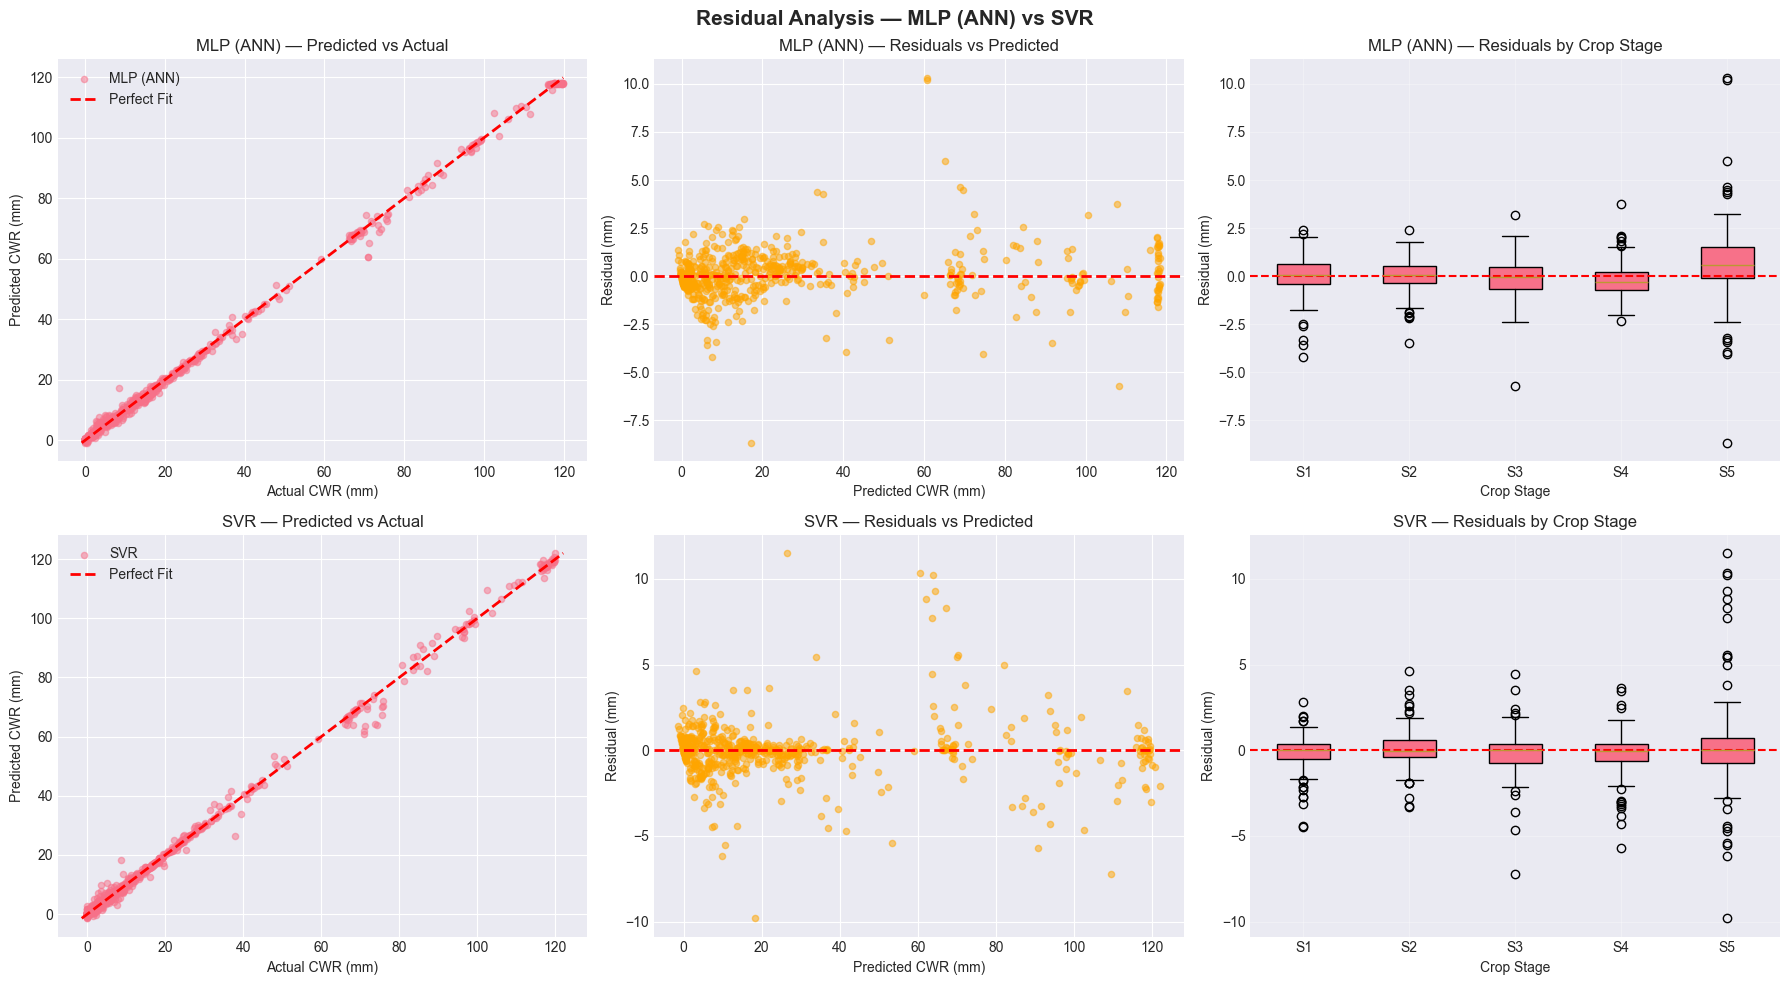

✓ Residual analysis saved → ./Visualisation/residual_analysis_svr_mlp.png


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Residual Analysis — MLP (ANN) vs SVR", fontsize=15, fontweight='bold')

y_test_arr = np.array(y_test)
models_res = [
    ("MLP (ANN)", np.array(mlp_results['y_pred'])),
    ("SVR",       np.array(svr_results['y_pred']))
]

for col, (name, y_pred) in enumerate(models_res):
    residuals = y_test_arr - y_pred

    # --- Predicted vs Actual ---
    axes[col, 0].scatter(y_test_arr, y_pred, alpha=0.5, s=20, label=name)
    lims = [min(y_test_arr.min(), y_pred.min()), max(y_test_arr.max(), y_pred.max())]
    axes[col, 0].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
    axes[col, 0].set_xlabel('Actual CWR (mm)')
    axes[col, 0].set_ylabel('Predicted CWR (mm)')
    axes[col, 0].set_title(f'{name} — Predicted vs Actual')
    axes[col, 0].legend()

    # --- Residuals vs Predicted ---
    axes[col, 1].scatter(y_pred, residuals, alpha=0.5, s=20, color='orange')
    axes[col, 1].axhline(0, color='red', linestyle='--', lw=2)
    axes[col, 1].set_xlabel('Predicted CWR (mm)')
    axes[col, 1].set_ylabel('Residual (mm)')
    axes[col, 1].set_title(f'{name} — Residuals vs Predicted')

    # --- Residuals by Crop Stage ---
    X_test_reset = X_test.reset_index(drop=True)
    stage_res    = {
        s: residuals[X_test_reset['Crop_Stage'].values == s]
        for s in range(1, 6)
    }
    axes[col, 2].boxplot(
        [stage_res[s] for s in range(1, 6)],
        labels=[f'S{s}' for s in range(1, 6)],
        patch_artist=True
    )
    axes[col, 2].axhline(0, color='red', linestyle='--', lw=1.5)
    axes[col, 2].set_xlabel('Crop Stage')
    axes[col, 2].set_ylabel('Residual (mm)')
    axes[col, 2].set_title(f'{name} — Residuals by Crop Stage')
    axes[col, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./Visualisation/residual_analysis_svr_mlp.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Residual analysis saved → ./Visualisation/residual_analysis_svr_mlp.png")


SHAP ANALYSIS — MLP (ANN)


  0%|          | 0/600 [00:00<?, ?it/s]

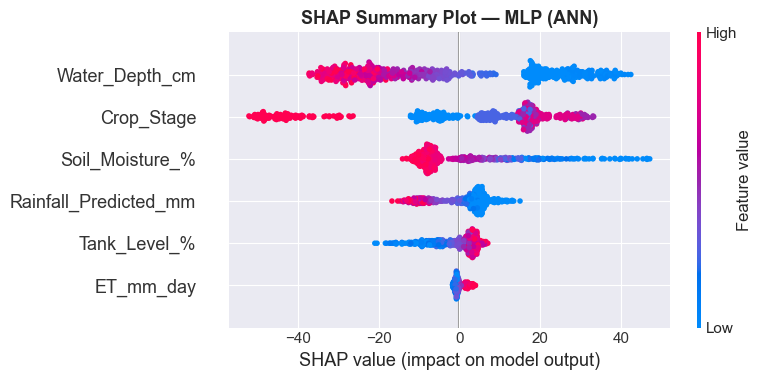

✓ MLP SHAP summary saved → ./Visualisation/shap_mlp_summary.png


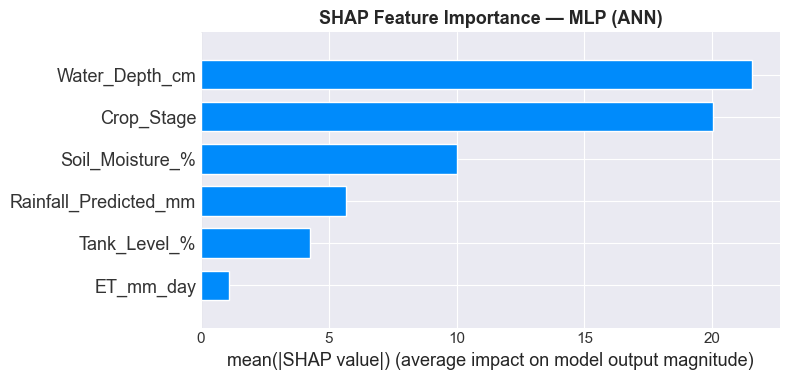

✓ MLP SHAP bar chart saved → ./Visualisation/shap_mlp_bar.png


In [23]:
print("=" * 70)
print("SHAP ANALYSIS — MLP (ANN)")
print("=" * 70)

# Use KernelExplainer for MLP (model-agnostic)
X_test_df       = pd.DataFrame(X_test_scaled, columns=feature_columns)
X_summary_mlp   = shap.sample(X_test_df, 100, random_state=42)  # background sample

mlp_explainer   = shap.KernelExplainer(best_mlp.predict, X_summary_mlp)
mlp_shap_values = mlp_explainer.shap_values(X_test_df, nsamples=200)

# Summary plot
plt.figure(figsize=(9, 5))
shap.summary_plot(
    mlp_shap_values, X_test_df,
    feature_names=feature_columns,
    plot_type='dot', show=False
)
plt.title("SHAP Summary Plot — MLP (ANN)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Visualisation/shap_mlp_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ MLP SHAP summary saved → ./Visualisation/shap_mlp_summary.png")

# Bar plot — mean |SHAP|
plt.figure(figsize=(8, 4))
shap.summary_plot(
    mlp_shap_values, X_test_df,
    feature_names=feature_columns,
    plot_type='bar', show=False
)
plt.title("SHAP Feature Importance — MLP (ANN)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Visualisation/shap_mlp_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ MLP SHAP bar chart saved → ./Visualisation/shap_mlp_bar.png")


SHAP ANALYSIS — SVR


  0%|          | 0/600 [00:00<?, ?it/s]

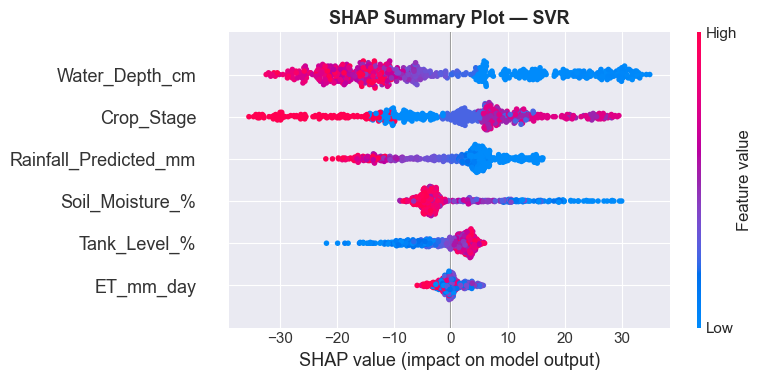

✓ SVR SHAP summary saved → ./Visualisation/shap_svr_summary.png


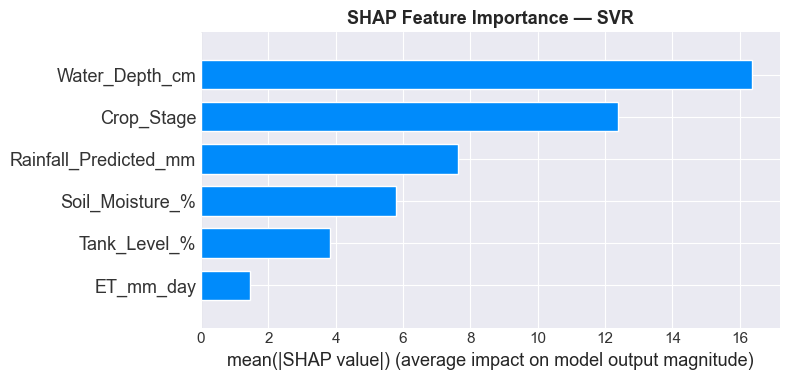

✓ SVR SHAP bar chart saved → ./Visualisation/shap_svr_bar.png


In [24]:
print("=" * 70)
print("SHAP ANALYSIS — SVR")
print("=" * 70)

X_summary_svr   = shap.sample(X_test_df, 100, random_state=42)
svr_explainer   = shap.KernelExplainer(best_svr.predict, X_summary_svr)
svr_shap_values = svr_explainer.shap_values(X_test_df, nsamples=200)

# Summary plot
plt.figure(figsize=(9, 5))
shap.summary_plot(
    svr_shap_values, X_test_df,
    feature_names=feature_columns,
    plot_type='dot', show=False
)
plt.title("SHAP Summary Plot — SVR", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Visualisation/shap_svr_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ SVR SHAP summary saved → ./Visualisation/shap_svr_summary.png")

# Bar plot
plt.figure(figsize=(8, 4))
shap.summary_plot(
    svr_shap_values, X_test_df,
    feature_names=feature_columns,
    plot_type='bar', show=False
)
plt.title("SHAP Feature Importance — SVR", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Visualisation/shap_svr_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ SVR SHAP bar chart saved → ./Visualisation/shap_svr_bar.png")


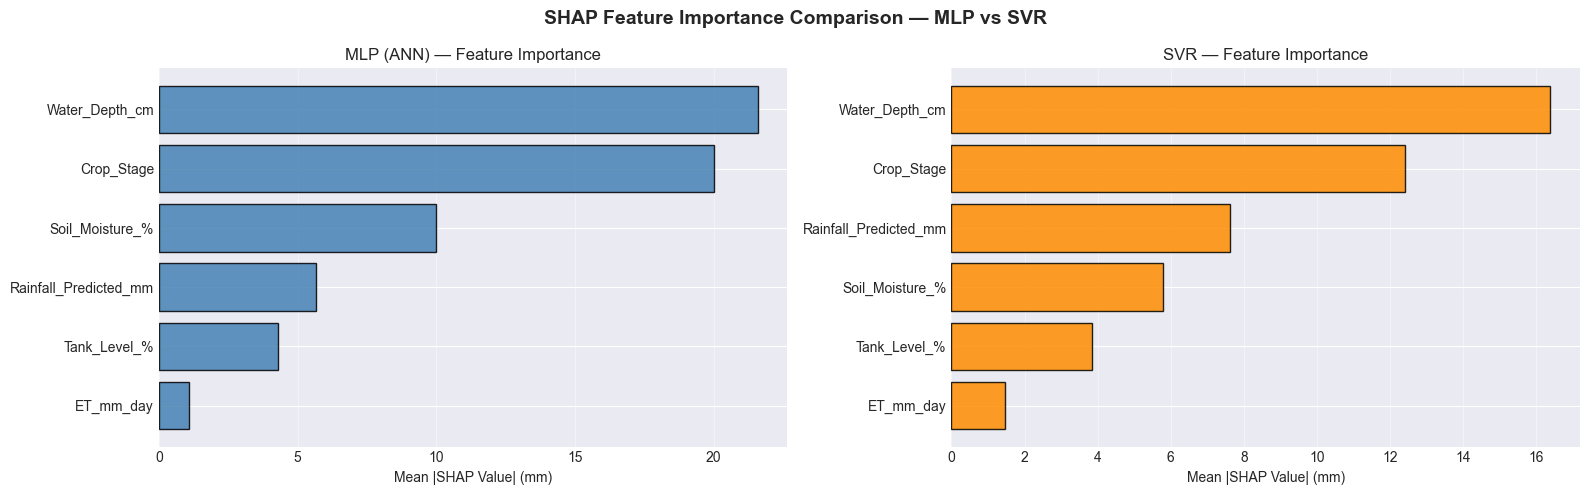

✓ SHAP comparison saved → ./Visualisation/shap_comparison_svr_mlp.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("SHAP Feature Importance Comparison — MLP vs SVR",
             fontsize=14, fontweight='bold')

# Mean absolute SHAP values
mlp_mean_shap = np.abs(mlp_shap_values).mean(axis=0)
svr_mean_shap = np.abs(svr_shap_values).mean(axis=0)

for ax, mean_shap, title, color in zip(
    axes,
    [mlp_mean_shap, svr_mean_shap],
    ["MLP (ANN)", "SVR"],
    ["steelblue", "darkorange"]
):
    sorted_idx = np.argsort(mean_shap)
    ax.barh(
        [feature_columns[i] for i in sorted_idx],
        mean_shap[sorted_idx],
        color=color, alpha=0.85, edgecolor='black'
    )
    ax.set_xlabel("Mean |SHAP Value| (mm)")
    ax.set_title(f"{title} — Feature Importance")
    ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('./Visualisation/shap_comparison_svr_mlp.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ SHAP comparison saved → ./Visualisation/shap_comparison_svr_mlp.png")


In [26]:
print("\n" + "=" * 70)
print("  FINAL SUMMARY — ANN (MLP) & SVR CWR PREDICTION")
print("=" * 70)

print(f"\n  {'Metric':<15} {'MLP (ANN)':>12} {'SVR':>12}")
print("  " + "-" * 42)
metrics = ['RMSE', 'MAE', 'R2', 'MAPE', 'Max_Error']
for m in metrics:
    unit = ' mm' if m in ['RMSE','MAE','Max_Error'] else (' %' if m == 'MAPE' else '')
    print(f"  {m:<15} {mlp_results[m]:>11.4f}{unit}  {svr_results[m]:>10.4f}{unit}")

print("\n  Saved Artifacts:")
print("   ./Models/final_mlp_cwr.pkl")
print("   ./Models/final_svr_cwr.pkl")
print("   ./Models/scaler_ann_svr.pkl")
print("   ./Visualisation/dataset_overview.png")
print("   ./Visualisation/residual_analysis_svr_mlp.png")
print("   ./Visualisation/shap_mlp_summary.png")
print("   ./Visualisation/shap_mlp_bar.png")
print("   ./Visualisation/shap_svr_summary.png")
print("   ./Visualisation/shap_svr_bar.png")
print("   ./Visualisation/shap_comparison_svr_mlp.png")
print("   ./Visualisation/model_comparison_svr_mlp.csv")

print("\n✓ Pipeline complete!")



  FINAL SUMMARY — ANN (MLP) & SVR CWR PREDICTION

  Metric             MLP (ANN)          SVR
  ------------------------------------------
  RMSE                 1.3618 mm      1.7778 mm
  MAE                  0.8672 mm      0.9938 mm
  R2                   0.9984      0.9973
  MAPE            239897088.9857 %  482718273.1750 %
  Max_Error           10.3250 mm     11.5035 mm

  Saved Artifacts:
   ./Models/final_mlp_cwr.pkl
   ./Models/final_svr_cwr.pkl
   ./Models/scaler_ann_svr.pkl
   ./Visualisation/dataset_overview.png
   ./Visualisation/residual_analysis_svr_mlp.png
   ./Visualisation/shap_mlp_summary.png
   ./Visualisation/shap_mlp_bar.png
   ./Visualisation/shap_svr_summary.png
   ./Visualisation/shap_svr_bar.png
   ./Visualisation/shap_comparison_svr_mlp.png
   ./Visualisation/model_comparison_svr_mlp.csv

✓ Pipeline complete!
